# Proyecto 9

El objetivo de este proyecto es ayudar a la empresa a optimizar los gastos de marketing para la empresa Showz

## Paso 1 - Preparacion de datos

### 1.1 - Importamos librerias

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

### 1.2 - Cargamos Archivos

In [2]:
visitas = pd.read_csv('visits_log_us.csv')
pedidos = pd.read_csv('orders_log_us.csv')
gastos = pd.read_csv('costs_us.csv')

### 1.3 - Primer vista a nuestros archivos

In [3]:
# Mostramos la informacion general del archivo
visitas.info()
# Mostramos las primeras filas para ver su contenido
display(visitas.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


Las columnas End ts y Start Ts estan como tipo object por lo cual es necesario convertirlas al formato de fecha, asi como los nombres de columnas estan en mayusculas y minusculas y separadas por espacios, por lo tenemos que corregirlos para facilitar el analisis.

In [4]:
print('Cantidad de datos duplicados:', visitas.duplicated().sum())
print('Cantidad de datos ausentes:', visitas.isna().sum())

Cantidad de datos duplicados: 0
Cantidad de datos ausentes: Device       0
End Ts       0
Source Id    0
Start Ts     0
Uid          0
dtype: int64


No hay filas duplicadas ni datos ausentes

In [5]:
# Mostramos la informacion general del archivo
pedidos.info()
# Mostramos las primeras filas para ver su contenido
display(pedidos.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


Al igual que nuestro archivo pasado, presenta errores en los nombres y en las columnas de fechas

In [6]:
print('Cantidad de datos duplicados:', pedidos.duplicated().sum())
print('Cantidad de datos ausentes:', pedidos.isna().sum())

Cantidad de datos duplicados: 0
Cantidad de datos ausentes: Buy Ts     0
Revenue    0
Uid        0
dtype: int64


Mismo caso, sin filas duplicadas ni datos ausentes.

In [7]:
# Mostramos la informacion general del archivo
gastos.info()
# Mostramos las primeras 5 filas para ver su contenido
display(gastos.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB


,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


este archivo solo presenta el problema con el tipo de fecha

In [8]:
print('Cantidad de datos duplicados:', gastos.duplicated().sum())
print('Cantidad de datos ausentes:', gastos.isna().sum())

Cantidad de datos duplicados: 0
Cantidad de datos ausentes: source_id    0
dt           0
costs        0
dtype: int64


Sin filas duplicadas ni archivos ausentes

### 1.4 - Correccion de archivos.

In [9]:
# Cambiamos los nombres de columnas
visitas.columns = ['device', 'end_ts', 'source_id', 'start_ts', 'uid']
# Comprobamos el cambio
visitas.head()

,device,end_ts,source_id,start_ts,uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


In [10]:
# Cambiamos al tipo de fecha
visitas['end_ts'] = pd.to_datetime(visitas['end_ts'])
visitas['start_ts'] = pd.to_datetime(visitas['start_ts'])
# Comprobamos el cambio
visitas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  object        
 1   end_ts     359400 non-null  datetime64[ns]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB


In [11]:
# Cambiamos los nombres de columnas 
pedidos.columns = ['buy_ts', 'revenue', 'uid']
# Comprobamos el cambio
pedidos.head()

,buy_ts,revenue,uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [12]:
# Cambiamos al tipo de fecha
pedidos['buy_ts'] = pd.to_datetime(pedidos['buy_ts'])
# Comprobamos el cambio
pedidos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


In [13]:
# Cambiamos al tipo de fecha
gastos['dt'] = pd.to_datetime(gastos['dt'])
# Comprobamos el cambio
gastos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB


Ya que realizamos las correcciones podemos continuar con nuestro analisis

## Paso 2 - Informes y metricas

### 2.1 Visitas

#### 2.1.1 Temdencias diarias, semanales y mensuales

##### 2.1.1.1 Visitas por dia

En este analisis por dia nos enfocaremos en comparar el primer mes de nuestro estudio con el mas reciente y ver que impacto han tenido las campañas de marketing en este lapso de tiempo.

In [14]:
# Extraemos la fecha sin las horas de la columna start_ts
visitas['date'] = visitas['start_ts'].dt.date
# Convertimos al tipo datetime
visitas['date'] = pd.to_datetime(visitas['date'])
# Agrupamos por fecha y contamos los usuarios unicos
usuarios_por_dia = visitas.groupby('date')['uid'].nunique().reset_index()
# Promedio de suarios diarios
usuarios_diarios_promedio = usuarios_por_dia['uid'].mean()
print('Promedio de usuarios al dia:', usuarios_diarios_promedio)

Promedio de usuarios al dia: 907.9917582417582


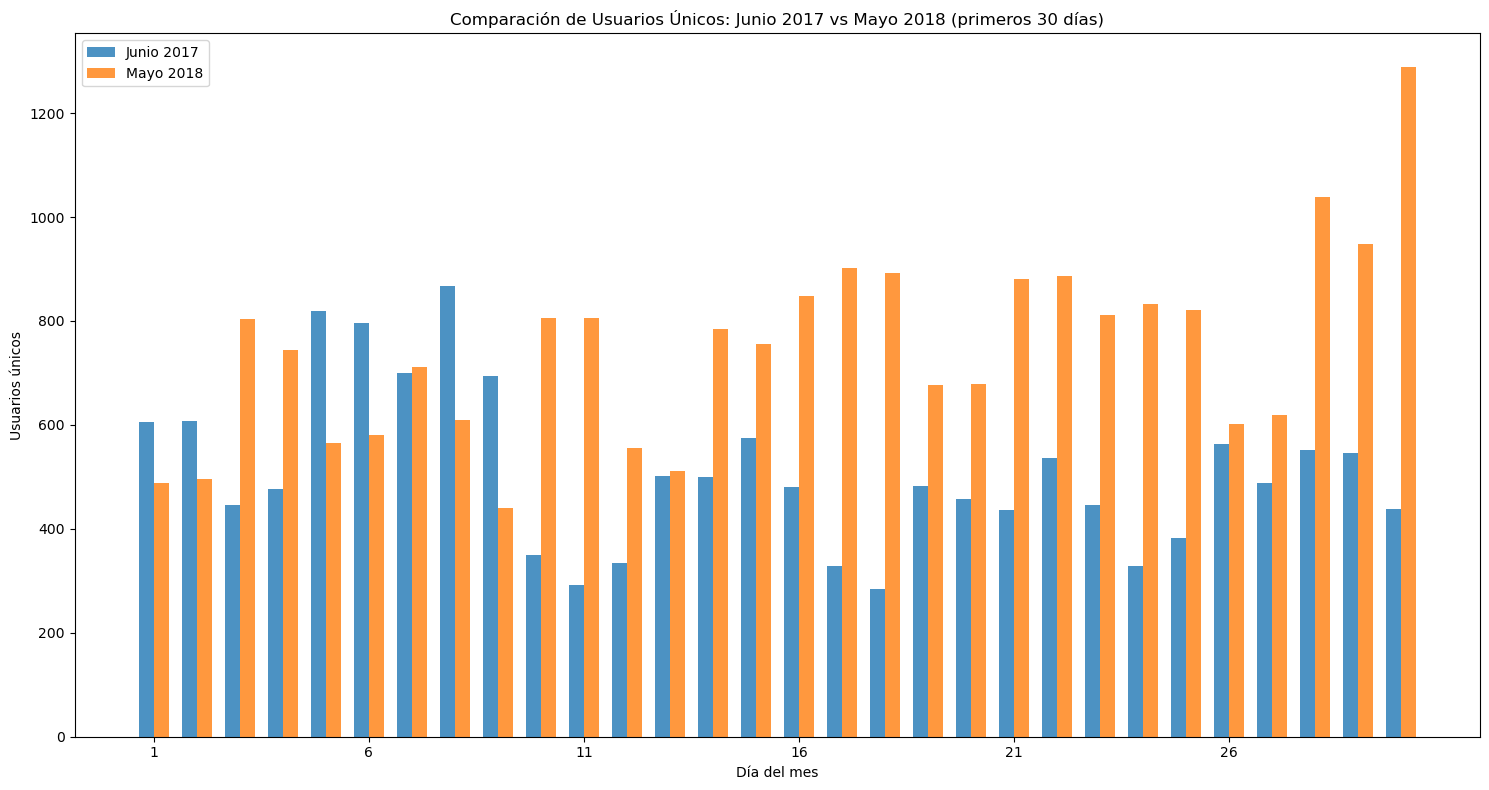

In [15]:
# identificamos los usuarios diarios del primer y ultimo mes
primer_mes = usuarios_por_dia[usuarios_por_dia['date'].dt.to_period('M') == usuarios_por_dia['date'].min().to_period('M')]
ultimo_mes = usuarios_por_dia[usuarios_por_dia['date'].dt.to_period('M') == usuarios_por_dia['date'].max().to_period('M')]
# Grafiquemos ambos meses para hacer una comparativa de usuarios desde el inicio hasta el mas actual
# Como las muestras de los meses no cuentan con la misma cantidad de dias, solo tomaremos los primeros 30 para continuar con el analisis
primer_mes_30 = primer_mes.head(30)
ultimo_mes_30 = ultimo_mes.head(30)

fig, ax = plt.subplots(figsize=(15, 8))
x_pos = np.arange(len(primer_mes_30))
width = 0.35

bars1 = ax.bar(x_pos - width/2, primer_mes_30['uid'], width, label='Junio 2017', alpha=0.8)
bars2 = ax.bar(x_pos + width/2, ultimo_mes_30['uid'], width, label='Mayo 2018', alpha=0.8)

ax.set_title('Comparación de Usuarios Únicos: Junio 2017 vs Mayo 2018 (primeros 30 días)')
ax.set_xlabel('Día del mes')
ax.set_ylabel('Usuarios únicos')
ax.set_xticks(x_pos[::5])  # Mostrar cada 5 días
ax.set_xticklabels([f'{primer_mes_30.iloc[i]["date"].day}' for i in range(0, len(primer_mes_30), 5)])
ax.legend()

plt.tight_layout()
plt.show()

Tras el analisis podemos ver que tenemos una media de 907 usuarios diarios y comparamos como a cambiado el trafico de usuarios entre el inicio (junio 2017) y el mas actual (mayo 2018) siendo el mas reciente un incremento mucho mayor al de sus inicios, lo cual sugiere que las estrategias de marketing implementadas en este periodo de tiempo han sido efectivas.

##### 2.1.1.2 Visitas por semana

Para el analsis semanal nos enfocaremos en las tendencias de los usuarios a lo largo del añó 2018

In [16]:
# Creamos una columna para identificar las semanas del año
visitas['week'] = visitas['date'].dt.isocalendar().week
# Agrupamos usuarios unicos por semana
usuarios_semana = visitas.groupby('week')['uid'].nunique().reset_index()
# Sacamos el promedio de usuarios unicos
semana_promedio = usuarios_semana['uid'].mean()
print(f'Promedio de usuarios unicos por semana: {semana_promedio:.2f}')

Promedio de usuarios unicos por semana: 5825.29


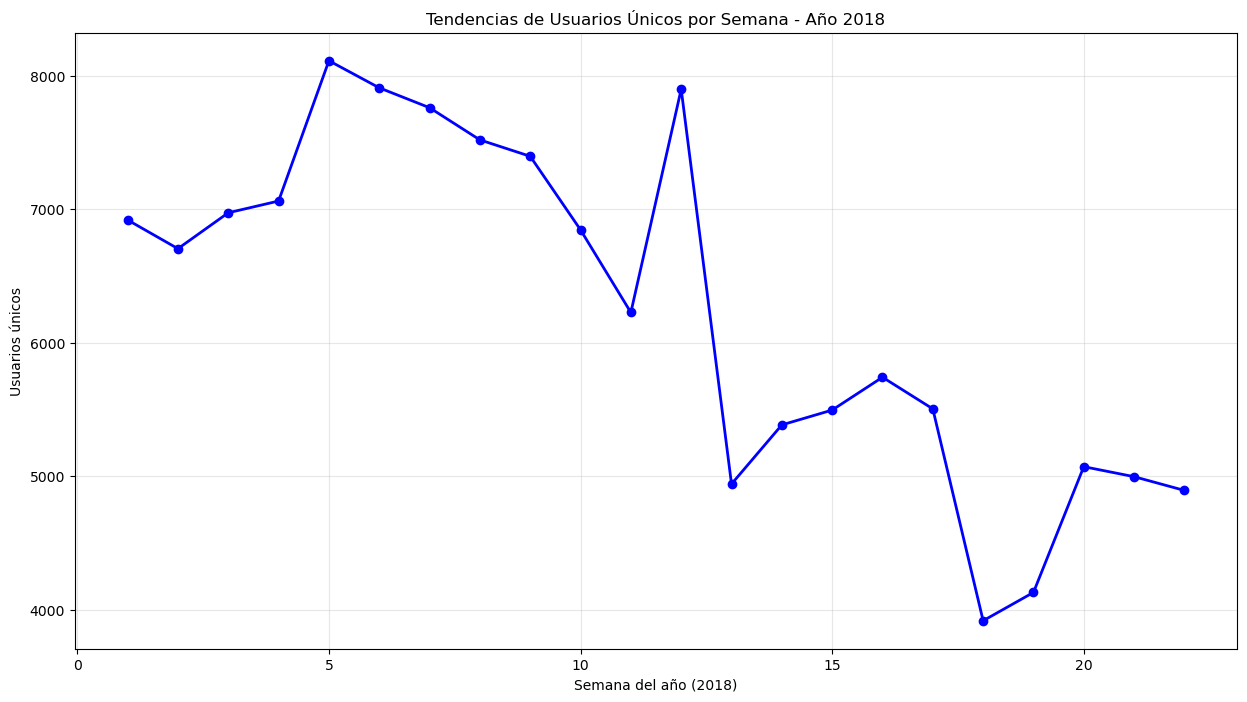

In [17]:
# Creamos una columna para el año
visitas['year'] = visitas['date'].dt.year
# Filtramos las visitas del año 2018
visitas_2018 = visitas[visitas['year'] == 2018]
# Agrupamos usuarios unicos por semana del año 2018
usuarios_semana2018 = visitas_2018.groupby('week')['uid'].nunique().reset_index()
# Creamos una grafica de lineas para mostrar las tendencias de los usuarios
plt.figure(figsize=(15, 8))
plt.plot(usuarios_semana2018['week'], usuarios_semana2018['uid'], 
         marker='o', linewidth=2, markersize=6, color='blue')
plt.title('Tendencias de Usuarios Únicos por Semana - Año 2018')
plt.xlabel('Semana del año (2018)')
plt.ylabel('Usuarios únicos')
plt.grid(True, alpha=0.3)
plt.show()

Podemos visualizar como al comienzo del año 2018 comenzamos con un trafico de 7000 usuarios por semana, teniendo su pico mas alto con mas de 8000 usuarios en la semana 5, luego de tener un a breve tendencia a descender hacia la semana 11 y recuperarse con alrededor de 7800 usuarios para la semana 12 y por ultimo desplomarse hasta los 4000 usuarios en la semana 18.

##### 2.1.1.3 Visitas mensuales

Para este analisis mensual haremos una comparativa entre el mes con mayor trafico contra el mes que menos usuarios estuvieron activos, esto nos ayuda para identificar cual fue el mes con una mejor campaña frente a la peor.

In [18]:
# Agregamos una columna para separar los meses
visitas['month'] = visitas['date'].dt.month
# Agrupamos usuarios unicos por mes
usuarios_mensuales = visitas.groupby('month')['uid'].nunique().reset_index()
# Sacamos el promedio de usuarios mensuales
promedio_mensual = usuarios_mensuales['uid'].mean()
print(f'Promedio de usuarios unicos mensuales: {promedio_mensual:.2f}')

Promedio de usuarios unicos mensuales: 23228.42


In [19]:
# Encontremos nuestro mes con mayor trafico y el menor
mes_max = usuarios_mensuales.loc[usuarios_mensuales['uid'].idxmax()]
mes_min = usuarios_mensuales.loc[usuarios_mensuales['uid'].idxmin()]
print(f"Mes con mayor trafico: {mes_max['month']} con {mes_max['uid']} usuarios")
print(f"Mes con menor trafico: {mes_min['month']} con {mes_min['uid']} usuarios")

Mes con mayor trafico: 11 con 32797 usuarios
Mes con menor trafico: 8 con 11631 usuarios


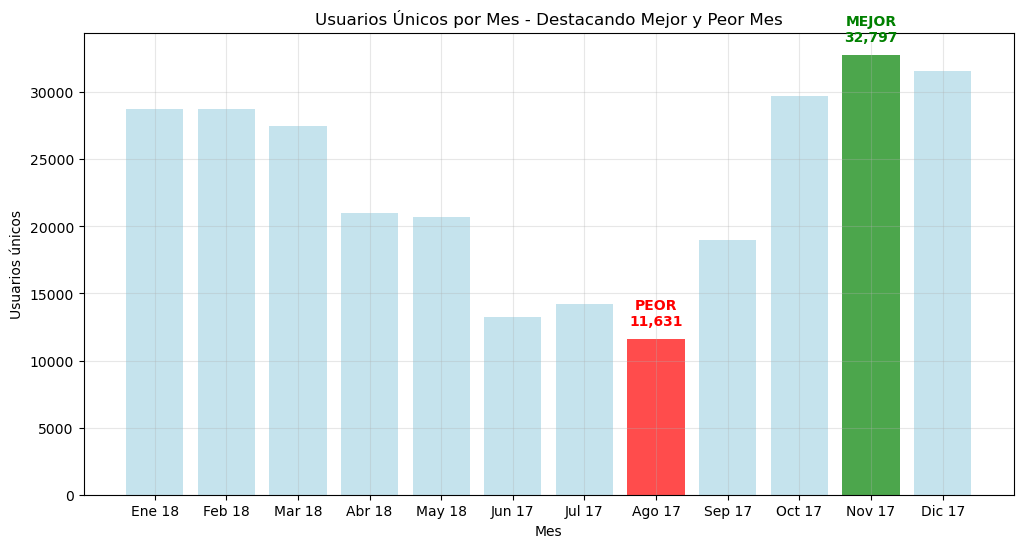

In [20]:
# Creamos una grafica comparativa
plt.figure(figsize=(12, 6))
colors = ['red' if x == mes_min['uid'] else 'green' if x == mes_max['uid'] else 'lightblue' 
          for x in usuarios_mensuales['uid']]

plt.bar(usuarios_mensuales['month'], usuarios_mensuales['uid'], color=colors, alpha=0.7)
plt.title('Usuarios Únicos por Mes - Destacando Mejor y Peor Mes')
plt.xlabel('Mes')
plt.ylabel('Usuarios únicos')
plt.xticks(range(1, 13), ['Ene 18', 'Feb 18', 'Mar 18', 'Abr 18', 'May 18', 'Jun 17', 
                          'Jul 17', 'Ago 17', 'Sep 17', 'Oct 17', 'Nov 17', 'Dic 17'])

# Añadir etiquetas en los meses extremos
plt.annotate(f'MEJOR\n{mes_max["uid"]:,}', 
             xy=(mes_max['month'], mes_max['uid']), 
             xytext=(mes_max['month'], mes_max['uid'] + 1000),
             ha='center', fontweight='bold', color='green')

plt.annotate(f'PEOR\n{mes_min["uid"]:,}', 
             xy=(mes_min['month'], mes_min['uid']), 
             xytext=(mes_min['month'], mes_min['uid'] + 1000),
             ha='center', fontweight='bold', color='red')

plt.grid(True, alpha=0.3)
plt.show()

Podemos ver una clara diferencia entre el mes de agosto del año 2017 que cuenta con apenas 11631 usuarios activos frente a noviembre del mismo año que casi triplica la cantidad de usuarios siendo estos 32797 usuarios activos, cantidad que no se vio muy disminuida en los meses posteriores contando con mas de 27000 usuarios activos hasta el mes de marzo donde hubo un breve descenso a los 20000 usuarios hasta el mes de mayo, seria recomendable revisar que se hizo en ambas campañas para determinar una mejor estrategia.

#### 2.1.2 Sesiones por dia

In [21]:
# Calculemos el total de sesiones por dia, primero contemos el total de sesiones
sesiones_diarias = visitas.groupby('date').size().reset_index(name='sesiones')
print(sesiones_diarias.head())
print()
# Calculemos el promedio de sesiones diarias
promedio_sesiones = sesiones_diarias['sesiones'].mean()
print(f'Sesiones diarias en promedio: {promedio_sesiones:.2f}')

        date  sesiones
0 2017-06-01       664
1 2017-06-02       658
2 2017-06-03       477
3 2017-06-04       510
4 2017-06-05       893

Sesiones diarias en promedio: 987.36


In [22]:
# Hagamos una comparacion entre los visitas diarias y las sesiones diarias
comparacion = sesiones_diarias.merge(usuarios_por_dia, on='date')
comparacion['ratio'] = comparacion['sesiones'] / comparacion['uid']
print(f"Promedio de sesiones por usuario único: {comparacion['ratio'].mean():.2f}")
print()
print(comparacion.head())

Promedio de sesiones por usuario único: 1.08

        date  sesiones  uid     ratio
0 2017-06-01       664  605  1.097521
1 2017-06-02       658  608  1.082237
2 2017-06-03       477  445  1.071910
3 2017-06-04       510  476  1.071429
4 2017-06-05       893  820  1.089024


La cantidad de sesiones diarias se asemeja a la cantidad de usuarios unicos por dia, lo cual implicaria que algunos de los usuarios inician sesion mas de una vez al dia.

#### 2.1.3 Duracion de las sesiones

In [23]:
# Calculemos la duracion de las sesiones
visitas['duration'] = (visitas['end_ts'] - visitas['start_ts']).dt.total_seconds()
# Calculemos el promedio de la duracion de las sesiones
promedio_duracion = (visitas['duration'].mean()) / 60 # dividimos entre 60 para convertirlos a minutos
print(f'Promedio de la duracion de las sesiones: {promedio_duracion:.2f} minutos')

Promedio de la duracion de las sesiones: 10.72 minutos


Los resultados muestran que las personas duran aproximadamente 10 min en decidir que es lo que necesitan.

#### 2.1.4 Frecuencia de regreso

In [24]:
# Contemos las sesiones de cada usuario
sesiones_usuarios = visitas.groupby('uid')['date'].count().reset_index(name='sesiones_usuarios')
print(sesiones_usuarios.head())

               uid  sesiones_usuarios
0   11863502262781                  1
1   49537067089222                  1
2  297729379853735                  1
3  313578113262317                  3
4  325320750514679                  2


In [25]:
# Calculemos la cantidad de usuarios que permanecieron activo asi como los que iniciaron sesion solo una vez
inactivos = sesiones_usuarios[sesiones_usuarios['sesiones_usuarios'] == 1]
activos = sesiones_usuarios[sesiones_usuarios['sesiones_usuarios'] > 1]
print('Cantidad de usuarios que regresaron:', len(activos))
print('Cantidad de usuarios que no volvieron:', len(inactivos))
print('Cantidad de usuarios totales:', len(sesiones_usuarios))

Cantidad de usuarios que regresaron: 52128
Cantidad de usuarios que no volvieron: 176041
Cantidad de usuarios totales: 228169


In [26]:
# Calculemos el porcentaje de usuarios que permanecieron activos
porcentaje_activos = len(activos) / len(sesiones_usuarios) * 100
# Calculemos el porcentaje de usuarios inactivos
porcentaje_inactivos = len(inactivos) / len(sesiones_usuarios) * 100
print(f'Porcentaje de usuarios activos: {porcentaje_activos:.2f}% usuarios')
print(f'Porcentaje de usuarios inactivos: {porcentaje_inactivos:.2f}% usuarios')

Porcentaje de usuarios activos: 22.85% usuarios
Porcentaje de usuarios inactivos: 77.15% usuarios


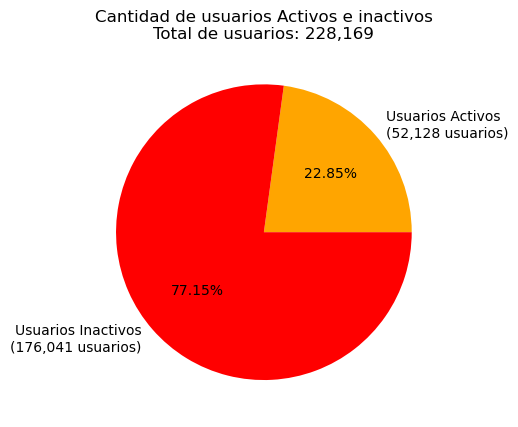

In [27]:
# Crearemos una grafica de pastel para presentar nuestros usuarios
valores = [len(activos), len(inactivos)]
etiquetas = [
    f'Usuarios Activos\n({len(activos):,} usuarios)',
    f'Usuarios Inactivos\n({len(inactivos):,} usuarios)'
]
colores = ['orange', 'red']
plt.pie(valores, labels=etiquetas, autopct='%1.2f%%', colors=colores)
plt.title(f'Cantidad de usuarios Activos e inactivos\nTotal de usuarios: {len(sesiones_usuarios):,}')
plt.show()

Tras analizar las sesiones de los usuarios podemos ver que solo el 22.85% (52,128) de los usuarios totales volvieron a iniciar sesion, mientras que el otro 77.15% (176,041) permanecieron inactivos luego de la primer sesion.

### 2.2 Ventas

#### 2.2.1 ¿Cuando empieza la gente a comprar?

Para responder esta pregunta primero tenemos que unir nuestras tablas de ventas y visitas para ver cuanto tiempo tardo la gente en decidir que comprar

In [28]:
# Unamos las tablas visitas y pedidos
ventas_union = visitas.merge(pedidos, on='uid', how='left')
print(ventas_union.head())

    device              end_ts  source_id            start_ts  \
0    touch 2017-12-20 17:38:00          4 2017-12-20 17:20:00   
1  desktop 2018-02-19 17:21:00          2 2018-02-19 16:53:00   
2    touch 2017-07-01 01:54:00          5 2017-07-01 01:54:00   
3  desktop 2018-05-20 11:23:00          9 2018-05-20 10:59:00   
4  desktop 2017-12-27 14:06:00          3 2017-12-27 14:06:00   

                    uid       date  week  year  month  duration  \
0  16879256277535980062 2017-12-20    51  2017     12    1080.0   
1    104060357244891740 2018-02-19     8  2018      2    1680.0   
2   7459035603376831527 2017-07-01    26  2017      7       0.0   
3  16174680259334210214 2018-05-20    20  2018      5    1440.0   
4   9969694820036681168 2017-12-27    52  2017     12       0.0   

               buy_ts  revenue  
0                 NaT      NaN  
1                 NaT      NaN  
2                 NaT      NaN  
3 2018-03-09 20:25:00     2.33  
4                 NaT      NaN  


In [29]:
# Limpiemos nuestra tabla de las columnas innecesarias para nuestro analisis
ventas = ventas_union.drop(['end_ts','date', 'week', 'year', 'month', 'duration'], axis=1)
display(ventas.head())

,device,source_id,start_ts,uid,buy_ts,revenue
0,touch,4,2017-12-20 17:20:00,16879256277535980062,NaT,NaN
1,desktop,2,2018-02-19 16:53:00,104060357244891740,NaT,NaN
2,touch,5,2017-07-01 01:54:00,7459035603376831527,NaT,NaN
3,desktop,9,2018-05-20 10:59:00,16174680259334210214,2018-03-09 20:25:00,2.33
4,desktop,3,2017-12-27 14:06:00,9969694820036681168,NaT,NaN


In [30]:
# Con nuestra tabla en limpio, busquemos el primer inicio de los usuarios y su primera compra
primer_compra = ventas.groupby('uid').agg({
    'start_ts': 'min',
    'buy_ts': 'min'
}).reset_index()
# Calculemos los dias que tardaron en comprar
conversion = primer_compra['buy_ts'] - primer_compra['start_ts']
# Convertimos a enteros
conversion_dias = conversion.dt.days
print(conversion_dias.head(10))

0      NaN
1      NaN
2      NaN
3    106.0
4      NaN
5      NaN
6      NaN
7      NaN
8      NaN
9      NaN
dtype: float64


A primer vista podemos notar que un usuario tardo 106 dias en convertir, lo cual sugiere que hay usuarios que tardan meses en convertirse a clientes.

In [31]:
# Filtremos los usuarios que compraron de los que no
usuarios_convertidos = conversion_dias.dropna()
usuarios_no_convertidos = conversion_dias.isna().sum()

print(f"Usuarios que compraron: {len(usuarios_convertidos)}")
print(f"Usuarios que NO compraron: {usuarios_no_convertidos}")
print(f"Tasa de conversión: {len(usuarios_convertidos) / len(conversion_dias) * 100:.2f}%")

Usuarios que compraron: 36523
Usuarios que NO compraron: 191646
Tasa de conversión: 16.01%


Podemos ver que la gran mayoria de usuarios no se convierten en clientes, solo el 16% de usuarios terminan comprando, ahora organicemos los usuarios en cohortes, los clasificaremos en 5 categorias, los inmediatos (el mismo dia de inicio compran), los que tardan entre 1 y 7 dias, los que tardan entre 8 y 30 dias, los que tardan mas de 30 dias, y por ultimo los que no convirtieron.

In [32]:
def categorizar_conversion(dias):
    if pd.isna(dias):
        return 'No convirtió'
    elif dias == 0:
        return 'Conversión inmediata'
    elif dias <= 7:
        return '1-7 días'
    elif dias <= 30:
        return '8-30 días'
    else:
        return 'Más de 30 días'

conversion_categorias = conversion_dias.apply(categorizar_conversion)
print(conversion_categorias.value_counts())

No convirtió            191646
Conversión inmediata     26363
Más de 30 días            4902
1-7 días                  3080
8-30 días                 2178
Name: count, dtype: int64


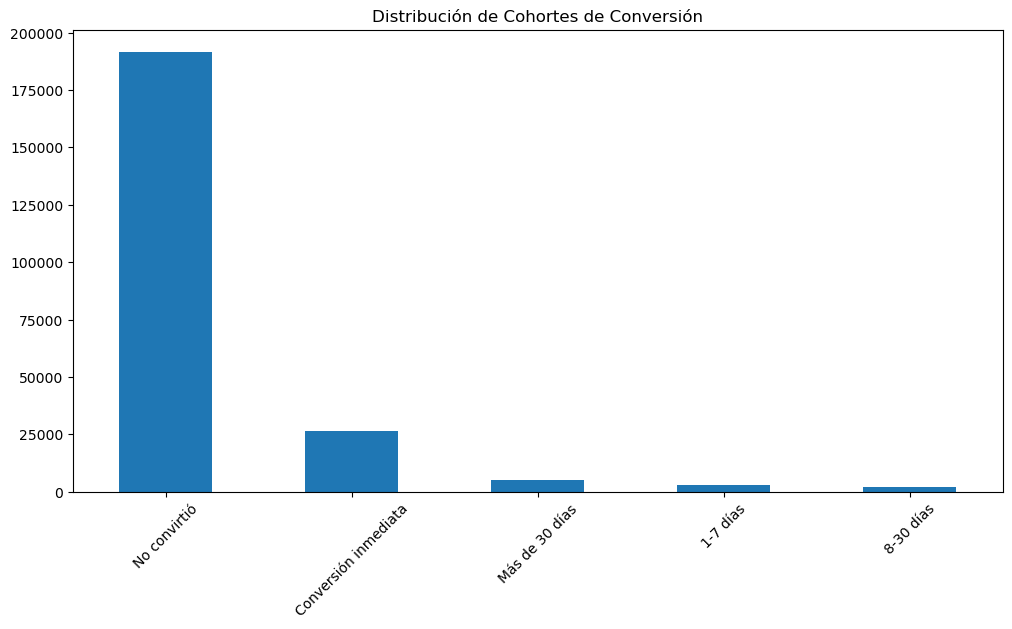

In [33]:
# Grafiquemos para tener un panorama mas amplio
plt.figure(figsize=(12, 6))
conversion_categorias.value_counts().plot(kind='bar')
plt.title('Distribución de Cohortes de Conversión')
plt.xticks(rotation=45)
plt.show()

Con una taza de conversion tan baja (16.01%) es normal ver una diferencia tan amplia entre las cohortes, sin embargo podemos apreciar que la mayoria de clientes fueron inmediatos (26363 usuarios).

#### 2.2.2 ¿Cuantos pedidos hacen en un periodo de tiempo dado?

In [34]:
# Calculemos la cantidad de pedidos por usuarios
pedidos_por_usuario = pedidos['uid'].value_counts().reset_index(name='pedidos')
# Calculemos los pedidos totales
pedidos_totales = pedidos_por_usuario['pedidos'].sum()
print(pedidos_por_usuario)
print(f'Pedidos totales: {pedidos_totales} pedidos')

                        uid  pedidos
0       3644482766749211722      239
1      13888745432979765063      238
2      11920452646463905188      227
3       6731421022966725351      183
4       5139615590553126732      150
...                     ...      ...
36518   1039442909910620438        1
36519     42362552951081637        1
36520   8069118931487899422        1
36521  17649287249444736221        1
36522     83872787173869366        1

[36523 rows x 2 columns]
Pedidos totales: 50415 pedidos


In [35]:
# Calculemos el promedio de pedidos por dia
pedidos_diarios = pedidos.groupby(pedidos['buy_ts'].dt.date).size().reset_index(name='pedidos_dia')
promedio_diario = pedidos_diarios['pedidos_dia'].mean()
print(f'Promedio de pedidos diarios: {promedio_diario:.2f} pedidos')

Promedio de pedidos diarios: 138.50 pedidos


In [36]:
# Calculemos el promedio de pedidos por semana
pedidos_semana = pedidos.groupby(pedidos['buy_ts'].dt.isocalendar().week).size().reset_index(name='pedidos_semana')
promedio_semana = pedidos_semana['pedidos_semana'].mean()
print(f'Promedio de pedidos semanales: {promedio_semana:.2f} pedidos')

Promedio de pedidos semanales: 969.52 pedidos


In [37]:
# Calculemos el promedio de pedidos por mes
pedidos_mes = pedidos.groupby(pedidos['buy_ts'].dt.month).size().reset_index(name='pedidos_mes')
promedio_mes = pedidos_mes['pedidos_mes'].mean()
print(f'Promedio de pedidos mensuales: {promedio_mes:.2f} pedidos')

Promedio de pedidos mensuales: 4201.25 pedidos


In [38]:
# Calculemos el promedio de pedidos por año
pedidos_año = pedidos.groupby(pedidos['buy_ts'].dt.year).size().reset_index(name='pedidos_año')
promedio_año = pedidos_año['pedidos_año'].mean()
print(f'Promedio de pedidos anuales: {promedio_año:.2f} pedidos')

Promedio de pedidos anuales: 25207.50 pedidos


Podemos ver que los promedios presentan numeros consistentes:

138.50 × 7 días = 969.5 ≈ 969.52 ✅

138.50 × 30 días = 4,155 ≈ 4,201.25 ✅

138.50 × 365 días = 50,552.5 vs 25,207.50 × 2 años = 50,415 ✅

#### 2.2.3 ¿Cual es el tamaño promedio de compra?

In [39]:
# Antes de responder a la pregunta, primero observemos algunos datos importantes
# Observemos la compra minima
compra_minima = pedidos['revenue'].min()
print(f'Compra minima: {compra_minima:.2f}')
# Observemos la compra maxima
compra_maxima = pedidos['revenue'].max()
print(f'Compra maxima: {compra_maxima:.2f}')
# Calculemos el promedio del tamaño de compra
compras_promedio = pedidos['revenue'].mean()
print(f'Promedio de compras: {compras_promedio:.2f}')
# Calculemos el total de los ingresos
total_ingresos = pedidos['revenue'].sum()
print(f'El Ingreso total fue de: ${total_ingresos:.2f}')

Compra minima: 0.00
Compra maxima: 2633.28
Promedio de compras: 5.00
El Ingreso total fue de: $252057.20


Al analizar estos datos podemos ver que nuestros datos podrian estar sesgados por esa compra de 2633.58, por lo cual es importante y mas presiso calcular la mediana

In [40]:
# Calculemos la mediana
compra_mediana = pedidos['revenue'].median()
print(f'Compra mediana: {compra_mediana}')

Compra mediana: 2.5


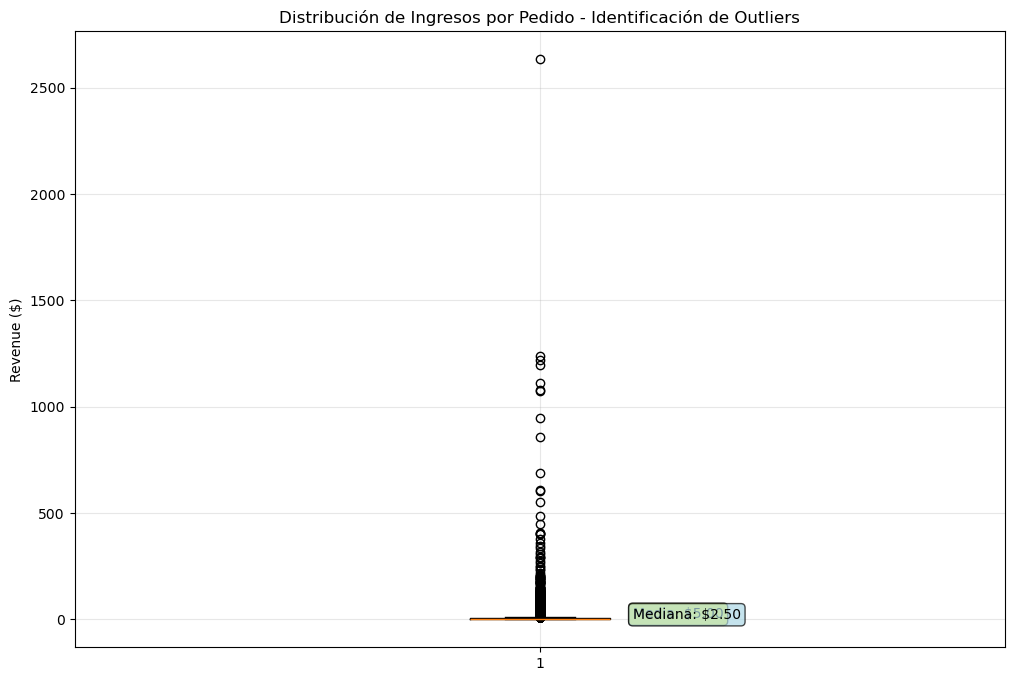

In [41]:
# Crear el boxplot para visualizar la distribución de revenue
plt.figure(figsize=(12, 8))
plt.boxplot(pedidos['revenue'], vert=True)
plt.title('Distribución de Ingresos por Pedido - Identificación de Outliers')
plt.ylabel('Revenue ($)')
plt.grid(True, alpha=0.3)

# Añadir estadísticas importantes como texto
plt.text(1.1, compras_promedio, f'Media: ${compras_promedio:.2f}', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
plt.text(1.1, compra_mediana, f'Mediana: ${compra_mediana:.2f}', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))

plt.show()

Tras el analisis podemos ver como hay muchos valores atipicos que sesgan nuestros datos, por eso la diferencia entre nuestra media y la mediana, por lo cual es mas presiso tomar la mediana como referencia.

#### 2.2.4 LTV (Lifetime Value)

Para calcular esta metrica necesitamos el total de pedidos y el total de clientes, para luego continuar con el calculo

In [42]:
# Calculemos el total de pedidos y de clientes
total_pedidos = pedidos_totales # ya habiamos calculado el total de pedidos en pasos anteriores asi que solo reasignamos la variable
total_clientes = pedidos['uid'].nunique()
promedio_compra_por_cliente = compra_mediana # de nuevo solo reasignamos la variable que ya tenemos 

# Ahora si calculemos el ltv con una sencilla formula
ltv = (total_pedidos / total_clientes) * promedio_compra_por_cliente
print(f' Cada cliente trae a la empresa durante su tiempo de vida un aproximado de: ${ltv:.2f}')

 Cada cliente trae a la empresa durante su tiempo de vida un aproximado de: $3.45


Utilizamos la mediana para ser mas precisos ya que el promedio esta sesgado por algunos valores atipicos.

De haber usado el promedio nos daria el doble y esto podria ser perjudicial a la hora de implementar alguna campaña, porque no podriamos obtener los resultados esperados

### 2.3 Markerting

#### 2.3.1 ¿Cuanto dinero se gasto?

Para responder a esta pregunta tenemos que calcular el gasto total, gastos por fuentes y los gastos a lo largo del tiempo.

In [43]:
# Calculemos el gasto total
gasto_total = gastos['costs'].sum()
print(f'El gasto total en marketing fue de: ${gasto_total:,}')

El gasto total en marketing fue de: $329,131.62


In [44]:
# Calculemos cuanto se gasto por cada fuente
gastos_por_fuentes = gastos.groupby('source_id')['costs'].sum().reset_index(name='gasto_total')
print(gastos_por_fuentes)

   source_id  gasto_total
0          1     20833.27
1          2     42806.04
2          3    141321.63
3          4     61073.60
4          5     51757.10
5          9      5517.49
6         10      5822.49


In [45]:
# Calculemos los gastos a lo largo del tiempo (dia, mes, año)
# Gasto diario
gasto_diario = gastos.groupby('dt')['costs'].sum().reset_index()
promedio_gasto_diario = gasto_diario['costs'].mean()
print(f'El promedio de gastos diarios es de: $ {promedio_gasto_diario:.2f}')
# Gasto mes
gastos['month'] = gastos['dt'].dt.month
gasto_mes = gastos.groupby('month')['costs'].sum().reset_index()
promedio_gasto_mes = gasto_mes['costs'].mean()
print(f'El promedio de gastos mensual es de: $ {promedio_gasto_mes:.2f}')
# Gasto anual
gastos['year'] = gastos['dt'].dt.year
gasto_año = gastos.groupby('year')['costs'].sum().reset_index()
promedio_gasto_año = gasto_año['costs'].mean()
print(f'El promedio de gastos anual es de: $ {promedio_gasto_año:.2f}')

El promedio de gastos diarios es de: $ 904.21
El promedio de gastos mensual es de: $ 27427.63
El promedio de gastos anual es de: $ 164565.81


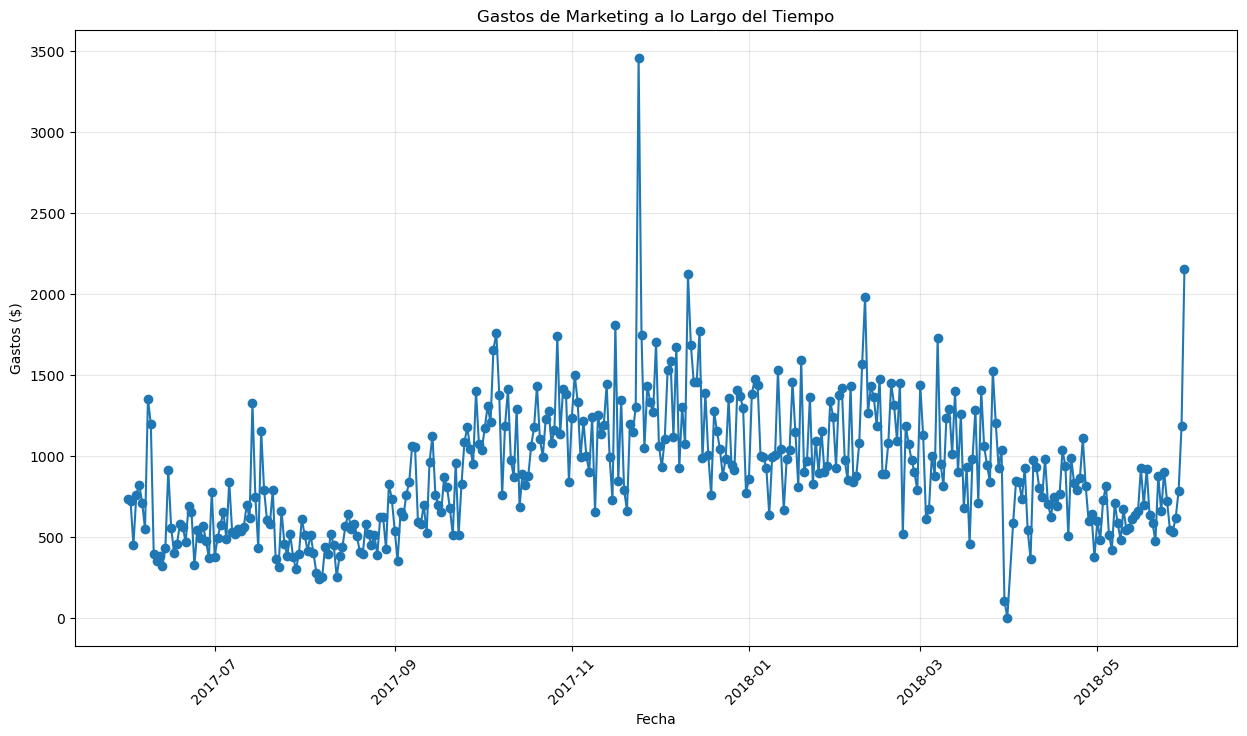

In [46]:
plt.figure(figsize=(15, 8))
plt.plot(gasto_diario['dt'], gasto_diario['costs'], marker='o')
plt.title('Gastos de Marketing a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Gastos ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

Podemos ver que en el periodo de noviembre/diciembre fue el pico mas alto en cuestion de gastos, y si recordamos en estas fechas fue cuando tuvimos los picos mas altos de trafico de usuarios.

#### 2.3.2 CAC (Costo de Adquisicion de Clientes)

Para calcular el CAC necesitamos aplicar la siguiente formula:

CAC = Gastos de marketing / Numero de clientes adquiridos

Para conseguirlo necesitamos calcular el gasto de cada fuente y calcular cuantos usuarios se convirtieron en  clientes, es decir, compraron algo, en periodos de 1 mes.

In [47]:
# Primero identifiquemos la primer visita de cada usuario para determinar de que fuente provienen
primera_visita = visitas.groupby('uid').agg({
    'source_id': 'first',  # La fuente de su primera visita
    'start_ts': 'min'      # Su primera fecha de visita
}).reset_index()

print("Primera visita por usuario:")
print(primera_visita.head())

Primera visita por usuario:
               uid  source_id            start_ts
0   11863502262781          3 2018-03-01 17:27:00
1   49537067089222          2 2018-02-06 15:55:00
2  297729379853735          3 2017-06-07 18:47:00
3  313578113262317          2 2017-09-18 22:49:00
4  325320750514679          5 2017-09-30 14:29:00


In [48]:
# necesitamos contar usuarios únicos que compraron
usuarios_convertidos = primera_visita.merge(
    pedidos[['uid']].drop_duplicates(),  # Solo usuarios únicos que compraron
    on='uid', 
    how='inner'
)
print(f"Usuarios únicos que se convirtieron: {len(usuarios_convertidos)}")

Usuarios únicos que se convirtieron: 36523


In [49]:
# Agregar columna de mes a las conversiones
usuarios_convertidos['month'] = pd.to_datetime(usuarios_convertidos['start_ts']).dt.to_period('M')

# Contar usuarios únicos convertidos por fuente y mes
conversiones_por_fuente_mes = usuarios_convertidos.groupby(['source_id', 'month'])['uid'].nunique().reset_index()
conversiones_por_fuente_mes.columns = ['source_id', 'month', 'clientes_adquiridos']

print("Conversiones por fuente y mes:")
print(conversiones_por_fuente_mes.head())

Conversiones por fuente y mes:
   source_id    month  clientes_adquiridos
0          1  2017-06                  293
1          1  2017-07                  265
2          1  2017-08                  167
3          1  2017-09                  318
4          1  2017-10                  427


In [50]:
# Preparar gastos por fuente y mes
gastos['month'] = gastos['dt'].dt.to_period('M')
gastos_por_fuente_mes = gastos.groupby(['source_id', 'month'])['costs'].sum().reset_index()

print("Gastos por fuente y mes:")
print(gastos_por_fuente_mes.head())

Gastos por fuente y mes:
   source_id    month    costs
0          1  2017-06  1125.61
1          1  2017-07  1072.88
2          1  2017-08   951.81
3          1  2017-09  1502.01
4          1  2017-10  2315.75


In [51]:
# Unamos nuestras tablas para poder calcular el CAC
union_tablas = gastos_por_fuente_mes.merge(conversiones_por_fuente_mes, on=['source_id', 'month'], how='inner')
display(union_tablas.head())

,source_id,month,costs,clientes_adquiridos
0,1,2017-06,1125.61,293
1,1,2017-07,1072.88,265
2,1,2017-08,951.81,167
3,1,2017-09,1502.01,318
4,1,2017-10,2315.75,427


In [52]:
union_tablas['cac'] = union_tablas['costs'] / union_tablas['clientes_adquiridos']
print(union_tablas)

    source_id    month    costs  clientes_adquiridos       cac
0           1  2017-06  1125.61                  293  3.841672
1           1  2017-07  1072.88                  265  4.048604
2           1  2017-08   951.81                  167  5.699461
3           1  2017-09  1502.01                  318  4.723302
4           1  2017-10  2315.75                  427  5.423302
..        ...      ...      ...                  ...       ...
79         10  2018-01   614.35                   95  6.466842
80         10  2018-02   480.88                  116  4.145517
81         10  2018-03   526.41                  156  3.374423
82         10  2018-04   388.25                  100  3.882500
83         10  2018-05   409.86                   90  4.554000

[84 rows x 5 columns]


In [53]:
# Calculemos el cac promedio 
cac_promedio = union_tablas['cac'].mean()
print(f'El CAC promedio es de: ${cac_promedio:.2f}')
# Recordemos que
print(f'El LTV promedio es de: ${ltv:.2f}')

El CAC promedio es de: $8.04
El LTV promedio es de: $3.45


In [54]:
cac_por_fuente = union_tablas.groupby('source_id')['cac'].mean().reset_index()
cac_por_fuente['diferencia_ltv'] = ltv - cac_por_fuente['cac']
print("perdidas por fuente:")
print(cac_por_fuente)

perdidas por fuente:
   source_id        cac  diferencia_ltv
0          1   5.611750       -2.160842
1          2  10.292400       -6.841492
2          3  15.732989      -12.282081
3          4   6.437690       -2.986783
4          5   7.688070       -4.237162
5          9   5.483953       -2.033046
6         10   5.029178       -1.578270


Al calcular el CAC nos podemos dar cuenta que supera el LTV de los clientes lo cual sugiere que la empresa esta teniendo problemas ya que gasta mas de lo que genera.

#### 2.3.3 ROMI

In [55]:

# Unir primera visita con pedidos para obtener ingresos por fuente
ingresos_por_fuente = primera_visita.merge(pedidos, on='uid', how='inner')
ingresos_por_fuente['month'] = pd.to_datetime(ingresos_por_fuente['start_ts']).dt.to_period('M')

# Agrupar ingresos por fuente y mes
ingresos_por_fuente_mes = ingresos_por_fuente.groupby(['source_id', 'month'])['revenue'].sum().reset_index()
print("Ingresos por fuente y mes:")
print(ingresos_por_fuente_mes.head())

Ingresos por fuente y mes:
   source_id    month   revenue
0          1  2017-06  12248.31
1          1  2017-07   2767.34
2          1  2017-08   2255.63
3          1  2017-09   2924.50
4          1  2017-10   3489.29


In [56]:
# Unir gastos, conversiones e ingresos
union_completa = gastos_por_fuente_mes.merge(
    conversiones_por_fuente_mes, 
    on=['source_id', 'month'], 
    how='inner'
).merge(
    ingresos_por_fuente_mes, 
    on=['source_id', 'month'], 
    how='inner'
)

# Recalcular CAC
union_completa['cac'] = union_completa['costs'] / union_completa['clientes_adquiridos']
print(union_completa.head())

   source_id    month    costs  clientes_adquiridos   revenue       cac
0          1  2017-06  1125.61                  293  12248.31  3.841672
1          1  2017-07  1072.88                  265   2767.34  4.048604
2          1  2017-08   951.81                  167   2255.63  5.699461
3          1  2017-09  1502.01                  318   2924.50  4.723302
4          1  2017-10  2315.75                  427   3489.29  5.423302


In [57]:
# Ahora sí podemos calcular ROMI correctamente
romi_por_fuente = union_completa.groupby('source_id').agg({
    'revenue': 'sum',      # Ingresos totales por fuente
    'costs': 'sum',        # Gastos totales por fuente
    'cac': 'mean'          # CAC promedio
}).reset_index()

# Calcular ROMI
romi_por_fuente['romi'] = (romi_por_fuente['revenue'] - romi_por_fuente['costs']) / romi_por_fuente['costs']
print("ROMI por fuente:")
print(romi_por_fuente)

ROMI por fuente:
   source_id   revenue      costs        cac      romi
0          1  38560.06   20833.27   5.611750  0.850889
1          2  65152.26   42806.04  10.292400  0.522034
2          3  44317.68  141321.63  15.732989 -0.686406
3          4  52479.75   61073.60   6.437690 -0.140713
4          5  40357.91   51757.10   7.688070 -0.220244
5          9   7076.98    5517.49   5.483953  0.282645
6         10   4111.34    5822.49   5.029178 -0.293886


A pesar de que en su mayoria las fuentes presentan perdidas, podemos rescatar las fuentes 1, 2, 9 que terminaron siendo rentables

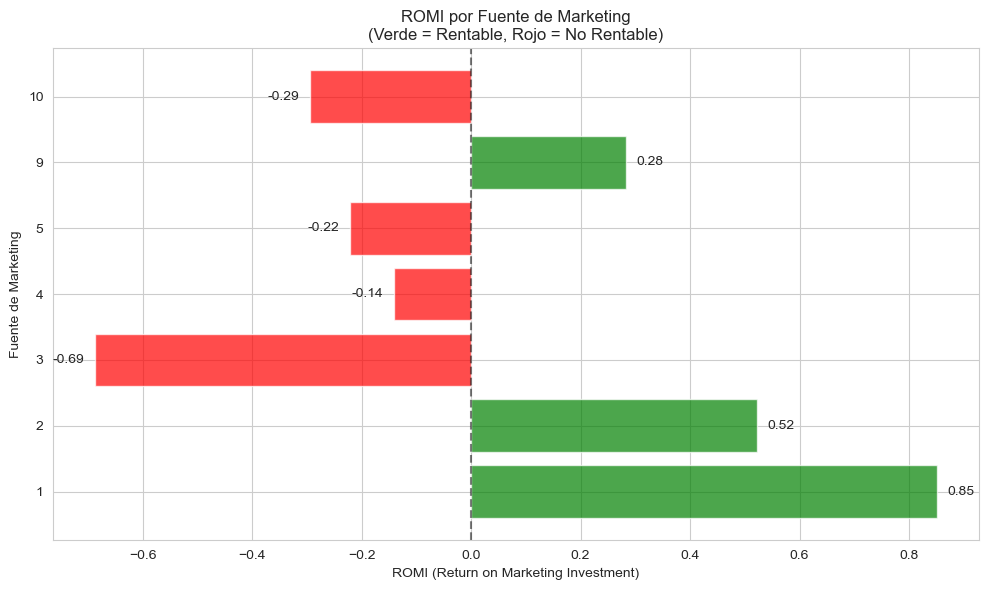

In [58]:
# Creemos una grafica horizontal para diferenciar las fuentes rentables de las que no
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Crear gráfico de barras horizontal
colors = ['green' if x > 0 else 'red' for x in romi_por_fuente['romi']]
bars = plt.barh(romi_por_fuente['source_id'].astype(str), romi_por_fuente['romi'], color=colors, alpha=0.7)

# Agregar línea en x=0 para separar rentables de no rentables
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)

# Personalizar el gráfico
plt.xlabel('ROMI (Return on Marketing Investment)')
plt.ylabel('Fuente de Marketing')
plt.title('ROMI por Fuente de Marketing\n(Verde = Rentable, Rojo = No Rentable)')

# Agregar valores en las barras
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + (0.02 if width > 0 else -0.02), bar.get_y() + bar.get_height()/2, 
             f'{width:.2f}', ha='left' if width > 0 else 'right', va='center')

plt.tight_layout()
plt.show()

### Paso 3 Conclusiones.

# Conclusiones y Recomendaciones - Análisis de Marketing Showz

A lo largo de este proyecto pudimos descubrir datos valiosos que nos ayudan a tomar decisiones fundamentadas basadas en métricas clave de marketing.

El análisis revela una situación crítica que requiere acción inmediata para optimizar la rentabilidad.

## Métricas Fundamentales

- **LTV (Lifetime Value):** \$3.45 - Valor promedio por cliente
- **CAC (Costo Adquisición):** \$8.04 - Costo promedio por cliente adquirido  
- **Pérdida por cliente:** -\$4.59 - CAC > LTV indica pérdidas significativas
- **Tasa de conversión:** 16.01% - Solo 1 de cada 6 visitantes compra

✅ Fuentes RENTABLES (Mantener y Escalar)
Fuente 1 - LA MÁS RENTABLE
- ROMI: +85.09%
- Ingresos: \$38,560
- Gastos: \$20,833  
- Ganancia Neta: +\$17,727

Fuente 2
- ROMI: +52.20%
- Ingresos: \$65,152
- Gastos: \$42,806
- Ganancia Neta: +\$22,346

Fuente 9
- ROMI: +28.26%
- Ingresos: \$7,077
- Gastos: \$5,517
- Ganancia Neta: +\$1,560

❌ Fuentes NO RENTABLES (Eliminar)
Fuente 3 - LA PEOR
- ROMI: -68.64%
- Ingresos: \$44,318
- Gastos: \$141,322
- Pérdida Neta: -\$97,004

Fuente 5
- ROMI: -22.02%
- Ingresos: \$40,358
- Gastos: \$51,757
- Pérdida Neta: -\$11,399

Fuente 4
- ROMI: -14.07%
- Ingresos: \$52,480
- Gastos: \$61,074
- Pérdida Neta: -\$8,594

Fuente 10
- ROMI: -29.39%
- Ingresos: \$4,111
- Gastos: \$5,822
- Pérdida Neta: -\$1,711

## Patrones Temporales Identificados

- **Mejor período:** Noviembre-Diciembre (32,797 usuarios en noviembre)
- **Peor período:** Agosto (11,631 usuarios)
- **Correlación:** Mayor gasto en marketing = Mayor tráfico = Mayor rentabilidad

## Recomendaciones Estratégicas

### Acciones Inmediatas

1. **ELIMINAR Fuente 3:** Representa el 83% de las pérdidas totales (\$97,004)
2. **ESCALAR Fuente 1:** Mayor ROMI (85%) - Incrementar presupuesto en 50%
3. **OPTIMIZAR Fuente 2:** Buen volumen pero mejorar eficiencia de costos

### Reasignación de Presupuesto Propuesta

- Reasignar presupuesto de las fuentes no rentables (3, 4, 5, 10) hacia las fuentes 1, 2 y 9
- Priorizar Fuente 1: Incrementar inversión dado su ROMI del 85%
- Optimizar o eliminar Fuente 3: Representa la mayor pérdida (\$97,004)